In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

In [2]:
NUM_CLIENTS=5
rounds=10
local_epochs=2
BATCH_SIZE=32
lr_rate=0.01

In [3]:
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0
X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def create_non_iid_clients(x, y):
    clients = {}
    # Client 1 -> Digits 0,1
    idx = np.where((y == 0) | (y == 1))[0]
    clients["client_1"] = (x[idx], y[idx])
    # Client 2 -> Digits 2,3
    idx = np.where((y == 2) | (y == 3))[0]
    clients["client_2"] = (x[idx], y[idx])
    # Client 3 -> Digits 4,5
    idx = np.where((y == 4) | (y == 5))[0]
    clients["client_3"] = (x[idx], y[idx])
    # Client 4 -> Digits 6,7
    idx = np.where((y == 6) | (y == 7))[0]
    clients["client_4"] = (x[idx], y[idx])
    # Client 5 -> Digits 8,9
    idx = np.where((y == 8) | (y == 9))[0]
    clients["client_5"] = (x[idx], y[idx])
    return clients

clients = create_non_iid_clients(X_train, Y_train)

In [5]:
def create_model():
  model=tf.keras.Sequential([
      Input(shape=(784,)),
      Dense(128,activation='relu'),
      Dense(64,activation='relu'),
      Dense(10,activation='softmax')
  ])

  model.compile(
     optimizer=SGD(learning_rate=lr_rate),
     loss='sparse_categorical_crossentropy',
     metrics=['accuracy']
 )
  return model

global_model=create_model()

In [6]:
def scale_weights(weights,factor):
  return [factor*w for w in weights]
def sum_scaled_weights(weight_list):
  avg=[]
  for weights in zip(*weight_list):
    avg.append(tf.reduce_sum(weights,axis=0))
  return avg

In [7]:
total_samples = sum(len(v[0]) for v in clients.values())
history=[]

for rnd in range(rounds):
  print(f"\n=======Round{rnd+1}=======")
  global_weights=global_model.get_weights()
  scaled_local_weights=[]
  for name,(cx,cy) in clients.items():
    local_model=create_model()
    local_model.set_weights(global_weights)
    local_model.fit(cx,cy,epochs=local_epochs,batch_size=BATCH_SIZE, verbose=1)
    local_weights=local_model.get_weights()
    factor=len(cx)/total_samples
    scaled_local_weights.append(scale_weights(local_weights,factor))
  averaged_weights=sum_scaled_weights(scaled_local_weights)
  global_model.set_weights(averaged_weights)
  loss,acc=global_model.evaluate(X_test,Y_test,verbose=1)
  history.append(acc)
  print('Test Accuracy:',acc)


=======Round1=======
Epoch 1/2
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9810 - loss: 0.1388
Epoch 2/2
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9977 - loss: 0.0122
Epoch 1/2
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9276 - loss: 0.2727
Epoch 2/2
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9680 - loss: 0.0963
Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9460 - loss: 0.2914
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - loss: 0.0558
Epoch 1/2
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.1635
Epoch 2/2
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9965 - loss: 0.0186
Epoch 1/2
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9264 - loss: 0.2851
Epoch 2/2
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.0878
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2565 - loss: 2.0808
Test Accuracy: 0.2565000057220459

=======Round2=====

In [8]:
print('Training Finished')
print('Final Accuracy:',history[-1])

Training Finished
Final Accuracy: 0.7315000295639038


Saved plot to fedavg_accuracy.png


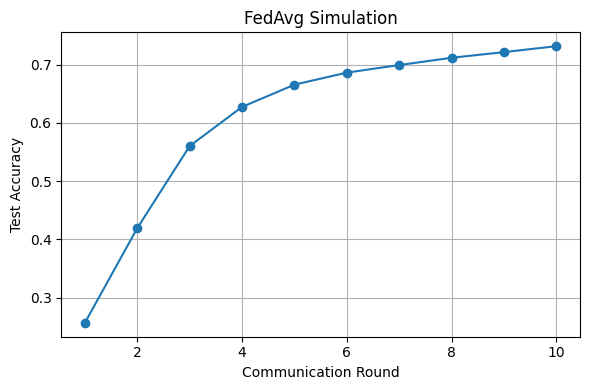

In [9]:
try:
    plt.figure(figsize=(6,4))
    plt.plot(range(1, rounds+1), history, marker="o")
    plt.xlabel("Communication Round")
    plt.ylabel("Test Accuracy")
    plt.title("FedAvg Simulation")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("fedavg_accuracy.png")
    print("Saved plot to fedavg_accuracy.png")
except Exception as e:
    print("Plot skipped:", e)